In [7]:
import os 
import subprocess

In [36]:
import json
import pandas as pd
import os
df = pd.read_csv("latin_square_design.csv")
index = 20
p1 = df.iloc[0]


#研究被験者の取得
participant = f"P{index+1}"
taskSet = p1["Task Set 1"]
condition_num = int(p1["Condition 1_ConditionNum"])




#ArrangeDataを取得する
with open(f"./NumericalAnalysis/ArrangeData/PreTaskArrangement{taskSet}.json", "r", encoding="utf-8") as f:
    arrangeData = json.loads(f.read())

with open(f"./NumericalAnalysis/VOICE_LOG/{participant}/{participant}_{condition_num}.json", "r", encoding="utf-8") as f:
    voice_log = json.loads(f.read())
    
with open(f"./NumericalAnalysis/RESULTS/{participant}/{participant}_{condition_num}.json", "r", encoding="utf-8") as f:
    result_data = json.loads(f.read())

FileNotFoundError: [Errno 2] No such file or directory: './NumericalAnalysis/VOICE_LOG/P21/P21_1.json'

In [35]:
task_index = 11

task = voice_log[task_index]
task["taskAttempts"]




[{'attemptId': '81ce9791-b60b-4e4a-a1b5-5d795037680d',
  'taskElapsedTime': '24.38037',
  'userCommand': 'あ、 一番左の、 天井のライト、 手前から順番に、 青、 シアン、 青、 にして',
  'outputDevices': []},
 {'attemptId': 'a915480c-58e6-4484-87ed-7861b880462e',
  'taskElapsedTime': '27.70044',
  'userCommand': '自分から見て 一番左の天井のライト三つを手前から順番に 青、シアン、青にして',
  'outputDevices': ['781e6091-cec9-4c26-9f3e-4d48d6d7570a',
   '58126407-cde0-4d62-a13d-1a24bf8ea5f3',
   '541d973c-4101-4118-ae52-f8f192b69655']},
 {'attemptId': '10f9be76-c2bb-45fe-b44e-ad880e37a0b6',
  'taskElapsedTime': '32.44055',
  'userCommand': '自分の 左側の一番奥の天井のライト三つを 手前から順番に青、シアン、青にして',
  'outputDevices': ['2dc8ca39-d023-42a5-874d-76fb312b5f00',
   'c689031b-92fe-41bc-a9bc-5f579631c813']},
 {'attemptId': 'bf8a323d-c954-4171-970f-bf3d962ae163',
  'taskElapsedTime': '0',
  'userCommand': '私の視界の中心の電気を青にして',
  'outputDevices': ['2125de35-62c2-40db-8bee-f0580a92ee8b',
   '2dc8ca39-d023-42a5-874d-76fb312b5f00',
   'c689031b-92fe-41bc-a9bc-5f579631c813']}]

In [5]:
import os 

os.getcwd()

'C:\\Users\\Tenma\\Desktop\\Keio\\InteractiveSmartHome\\InteractiveSmartHome\\Experiment'

In [2]:
def evaluate_all_predictions(output_data_list, arrange_data_list):
    results = []

    # arrange_data を dict に変換して素早くアクセス
    arrange_map = {
        entry["device_arrange_id"]: [dev["deviceId"] for dev in entry["devices"]]
        for entry in arrange_data_list
    }

    for output in output_data_list:
        task_id = output.get("task_id")
        predicted_ids = [d["id"] for d in output.get("selected_devices", [])]
        ground_truth_ids = arrange_map.get(task_id)

        if ground_truth_ids is None:
            print(f"[⚠️ Warning] Ground truth not found for task_id: {task_id}")
            continue

        gt_set = set(ground_truth_ids)
        pred_set = set(predicted_ids)

        true_positives = gt_set & pred_set
        false_positives = pred_set - gt_set
        false_negatives = gt_set - pred_set

        precision = len(true_positives) / len(pred_set) if pred_set else 0
        recall = len(true_positives) / len(gt_set) if gt_set else 0

        results.append({
            "task_id": task_id,
            "ground_truth": ground_truth_ids,
            "predicted": predicted_ids,
            "true_positives": list(true_positives),
            "false_positives": list(false_positives),
            "false_negatives": list(false_negatives),
            "precision": precision,
            "recall": recall
        })

    return results


In [1]:
results = evaluate_all_predictions(outputData, arrangeData)
import pprint
pprint.pprint(results)


NameError: name 'evaluate_all_predictions' is not defined

In [12]:
import pandas as pd
import re

# CSVの読み込み
condition = pd.read_csv("latin_square_design.csv")

# 変換用マッピング
replace_map = {
    "FD+SR": "空間参照だけ",
    "Pointing": "ポインティングだけ",
    "Pointing+SR": "Pointing+空間参照",
    "Label": "ラベル"
}

# Condition列だけを対象に処理
for col in condition.columns:
    if "Condition" in col:
        # ()の中の数字を取り出し、新しい列に保存
        condition[col + "_ConditionNum"] = condition[col].str.extract(r"\((\d+)\)").astype(float)

        # ()を除いた本体部分を変換
        condition[col] = condition[col].str.replace(r"\(\d+\)", "", regex=True).str.strip()
        condition[col] = condition[col].replace(replace_map)

# 結果を表示
condition.to_csv("./latin_square_design.csv", index=False)

# Average Attempts

In [40]:
import os
import json
import pandas as pd

# データの保存先
base_dir = "./NumericalAnalysis/VOICE_LOG"
participants = [f"P{i}" for i in range(1, 22)]  # P1〜P21
conditions = [1, 2, 3, 4]

# 結果を保存するリスト
records = []

for participant in participants:
    for condition in conditions:
        file_path = os.path.join(base_dir, participant, f"{participant}_{condition}.json")
        if not os.path.exists(file_path):
            print(f"❌ Missing: {file_path}")
            continue
        
        with open(file_path, "r", encoding="utf-8") as f:
            try:
                tasks = json.load(f)
            except json.JSONDecodeError:
                print(f"❌ JSON error: {file_path}")
                continue

        total_attempts = 0
        for task in tasks:
            # taskAttemptCountが正しくない可能性もあるので、taskAttemptsのlenを使う
            task_attempts = task.get("taskAttempts", [])
            total_attempts += len(task_attempts)

        avg_attempts = total_attempts / len(tasks) if tasks else 0

        records.append({
            "participant": participant,
            "condition": condition,
            "total_attempts": total_attempts,
            "average_attempts": avg_attempts
        })

# データフレームに変換して確認
df_attempts = pd.DataFrame(records)
print(df_attempts)


❌ Missing: ./NumericalAnalysis/VOICE_LOG\P12\P12_3.json
   participant  condition  total_attempts  average_attempts
0           P1          1              18          1.500000
1           P1          2              15          1.250000
2           P1          3              36          3.000000
3           P1          4              21          1.750000
4           P2          1              26          2.166667
..         ...        ...             ...               ...
78         P20          4              25          2.083333
79         P21          1              20          1.666667
80         P21          2              14          1.166667
81         P21          3              23          1.916667
82         P21          4              18          1.500000

[83 rows x 4 columns]


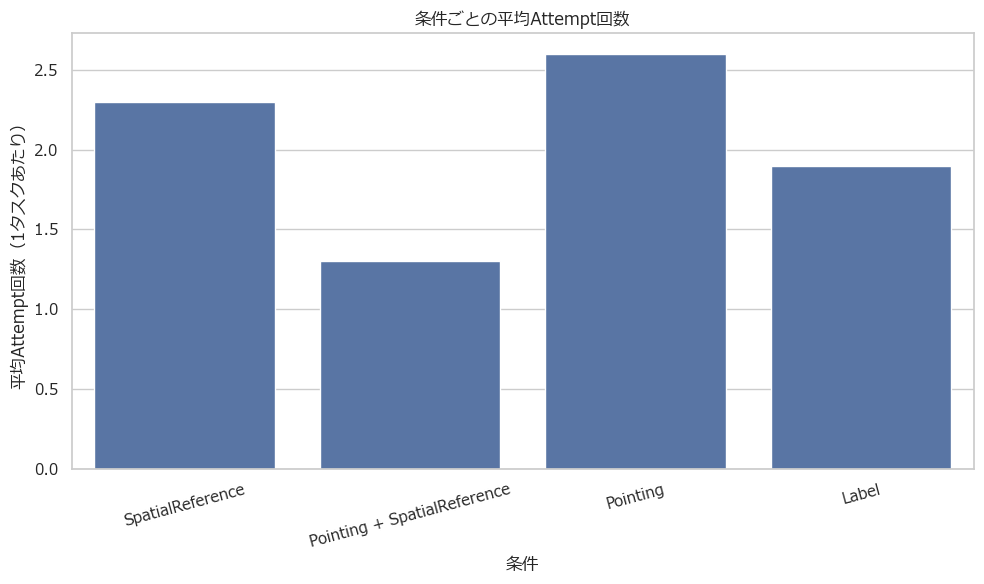

In [56]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import seaborn as sns
import pandas as pd

# 明示的にMeiryoフォントを指定（Windows用）
font_path = "C:/Windows/Fonts/meiryo.ttc"
font_prop = font_manager.FontProperties(fname=font_path)
rcParams['font.family'] = font_prop.get_name()

# 仮のデータ（あなたの df_attempts の groupby結果に相当）
data = {
    "condition": [1, 2, 3, 4],
    "average_attempts": [2.3, 1.3, 2.6, 1.9]
}
df = pd.DataFrame(data)

# 条件番号をラベルに変換
condition_labels = {
    1: "SpatialReference",
    2: "Pointing + SpatialReference",
    3: "Pointing",
    4: "Label"
}
df["condition_label"] = df["condition"].map(condition_labels)

# グラフ描画
plt.figure(figsize=(10, 6))
sns.barplot(x="condition_label", y="average_attempts", data=df)
plt.title("条件ごとの平均Attempt回数", fontproperties=font_prop)
plt.xlabel("条件", fontproperties=font_prop)
plt.ylabel("平均Attempt回数（1タスクあたり）", fontproperties=font_prop)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


# ElapsedTime

❌ Missing: ./NumericalAnalysis/VOICE_LOG\P12\P12_3.json


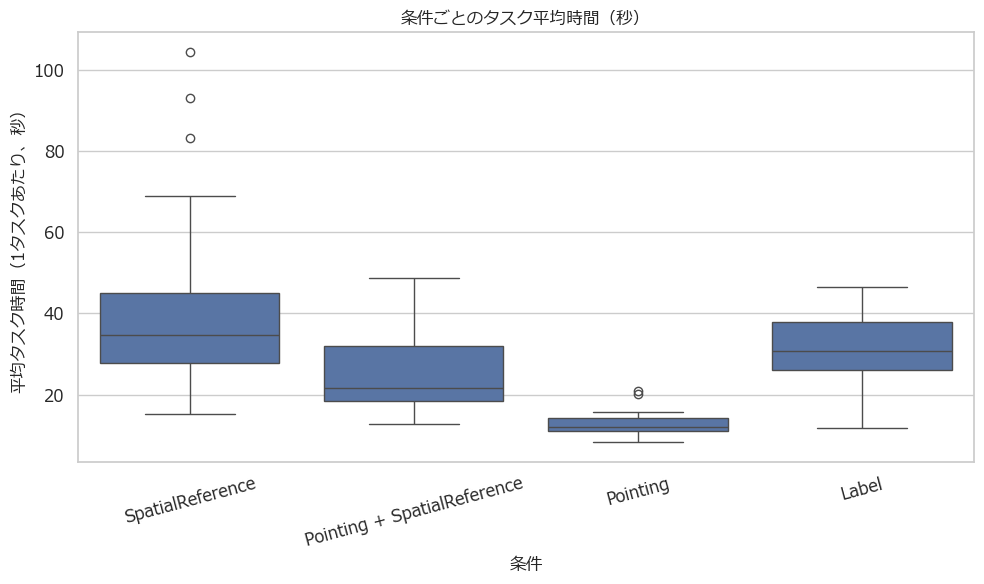

In [55]:
import os
import json
import pandas as pd

# データのパス
base_dir = "./NumericalAnalysis/VOICE_LOG"
participants = [f"P{i}" for i in range(1, 22)]
conditions = [1, 2, 3, 4]

records = []

for participant in participants:
    for condition in conditions:
        file_path = os.path.join(base_dir, participant, f"{participant}_{condition}.json")
        if not os.path.exists(file_path):
            print(f"❌ Missing: {file_path}")
            continue

        with open(file_path, "r", encoding="utf-8") as f:
            try:
                tasks = json.load(f)
            except json.JSONDecodeError:
                print(f"❌ JSON error: {file_path}")
                continue

        total_elapsed_time = 0.0
        total_task_count = 0

        for task in tasks:
            task_time = 0.0
            for attempt in task.get("taskAttempts", []):
                try:
                    task_time += float(attempt.get("taskElapsedTime", 0))
                except ValueError:
                    pass  # 変なデータは無視
            total_elapsed_time += task_time
            total_task_count += 1

        avg_task_time = total_elapsed_time / total_task_count if total_task_count > 0 else 0

        records.append({
            "participant": participant,
            "condition": condition,
            "total_time": total_elapsed_time,
            "average_task_time": avg_task_time
        })

df_time = pd.DataFrame(records)


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib import font_manager, rcParams

# 明示的に日本語フォント設定（Windows用）
font_path = "C:/Windows/Fonts/meiryo.ttc"
font_prop = font_manager.FontProperties(fname=font_path)
rcParams['font.family'] = font_prop.get_name()

# ここに df_time がすでに存在している想定
# 例: df_time = pd.DataFrame(records)

# 条件番号 → 名前に変換
condition_labels = {
    1: "SpatialReference",
    2: "Pointing + SpatialReference",
    3: "Pointing",
    4: "Label"
}
df_time["condition_label"] = df_time["condition"].map(condition_labels)

# 可視化
plt.figure(figsize=(10, 6))
sns.boxplot(x="condition_label", y="average_task_time", data=df_time)
plt.title("条件ごとのタスク平均時間（秒）", fontproperties=font_prop)
plt.xlabel("条件", fontproperties=font_prop)
plt.ylabel("平均タスク時間（1タスクあたり、秒）", fontproperties=font_prop)
plt.xticks(rotation=15, fontproperties=font_prop)
plt.yticks(fontproperties=font_prop)
plt.tight_layout()
plt.show()
